# HydroSeason: Under the Hood — Full Building-Blocks Walkthrough

**What this shows:** every lower-level building block `run_hydroseason`
wraps, called directly and in order — quality flagging, seasonal-pattern
classification, a workflow gate, dynamic hydrological-year detection,
monthly anomaly/condition screening, visualization, and HTML report
generation. Useful when you need to inspect or customize an intermediate
step the orchestrator doesn't expose.

**Requirements:** core install for the CSV fallback path; `matplotlib` for
the inline plot (optional); `hydroseason[stac]` only if `RUN_REMOTE_STAC` is
set to `True` below.

**Network:** none by default (`RUN_REMOTE_STAC = False` in the Setup cell
below, so it falls back to a local CSV path — generating synthetic data if
that path doesn't exist yet). Set `RUN_REMOTE_STAC = True` for a real DEA
STAC run.

**Runtime:** a few seconds on the default offline/fallback path.

For most use cases, prefer [01_quickstart.ipynb](01_quickstart.ipynb)
(`run_hydroseason`, the one-call orchestrator) instead. This notebook is the
runnable reference for what that orchestrator does internally.

It starts from monthly surface-water extent, classifies the seasonal structure,
selects suitable analyses, detects hydrological years, labels individual months,
runs condition/anomaly workflows, visualizes results, and writes an interactive
HTML report.

Default input source is STAC/WOfS monthly water masks. A CSV monthly-extent
path is included as a deterministic offline option and fallback; downstream
analysis is identical because both paths converge on `extent_pct` / `invalid_pct`.

Terminology note: HydroSeason reports surface-water extent timing and condition.
The stress screen below is a surface-water extent screening table, not discharge,
volume, drought, ecological condition, or causal attribution.

## 1. Imports

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:  # matplotlib is optional for the core CSV/report workflow
    plt = None

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "hydroseason").is_dir() and (candidate / "notebooks").is_dir():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hydroseason import (
    analyze_hydrological_state,
    classify_seasonal_pattern,
    detect_hydrological_years,
    generate_html_report,
    label_hydrological_months,
    suggest_hydro_year_config,
)
from hydroseason.examples import (
    dynamic_hydro_years_for_report,
    flag_extent_quality,
    load_workflow_extent,
)

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

print("Imports successful")

Imports successful


## 2. Setup

In [2]:
# INPUT_SOURCE selects the acquisition path. Defaults to the committed
# case-study CSV so this notebook is reproducible offline; set "stac" with
# RUN_REMOTE_STAC = True below for a real DEA fetch (see
# 02_dea_acquisition.ipynb for what that path actually does).
INPUT_SOURCE = "csv"

# REPORT_PATH is the self-contained HTML summary written by the final step.
REPORT_PATH = NOTEBOOK_DIR / "output" / "04_under_the_hood" / "report.html"

# CATCHMENT_KEY selects the real catchment CSV used when CSV is selected or
# when the offline STAC fallback is active.
CATCHMENT_KEY = "fitzroy_river_wa"

# RESOLUTION selects the precomputed catchment sample-area resolution.
RESOLUTION = "30m"

# RUN_REMOTE_STAC controls whether this notebook actually queries the remote
# STAC catalog. Keep False for offline documentation/tests; set True for a real run.
RUN_REMOTE_STAC = False

# CSV_FALLBACK_WHEN_STAC_DISABLED keeps the default STAC notebook runnable when
# RUN_REMOTE_STAC is False or optional STAC dependencies are unavailable.
CSV_FALLBACK_WHEN_STAC_DISABLED = True

# STAC_URL is the catalog endpoint used by the default WOfS acquisition path.
STAC_URL = "https://explorer.dea.ga.gov.au/stac"

# COLLECTION is the DEA Landsat WOfS product queried through STAC.
COLLECTION = "ga_ls_wo_3"

# AOI_PATH points to the polygon used to clip raster/STAC water masks.
AOI_PATH = PROJECT_ROOT / "data" / "fitzroy_kimberley_aoi.geojson"

# OUTPUT_CRS is the projected CRS used for WOfS loading and AOI clipping.
OUTPUT_CRS = 3577

# START_DATE and END_DATE bound the monthly water-extent analysis period.
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"

# CSV_DATA_ROOT is the committed case-study extent directory -- tracked in
# git, so this resolves in a fresh clone. (It previously pointed under
# output/, which is gitignored: on a clean checkout the file was missing
# and the loader silently substituted SYNTHETIC data that looked real.)
CSV_DATA_ROOT = PROJECT_ROOT / "case_studies" / "data" / "extent"
# DATA_PATH is derived from the selected catchment and resolution.
DATA_PATH = CSV_DATA_ROOT / f"{CATCHMENT_KEY}_{RESOLUTION}.csv"

# TIME_BLOCK bounds monthly STAC extent computation by reducing this many time steps per chunk.
TIME_BLOCK = 12

# RESOLUTION_M is the load resolution in metres passed to the STAC path. None
# lets the loader use its own default; set explicitly to match a known-good
# resolution (e.g. from plan_resolution) for a real run.
RESOLUTION_M = None

# TILE_PIXELS opts into the tiled STAC load: the AOI is split into
# TILE_PIXELS x TILE_PIXELS chunks and each tile is queried/loaded
# separately, instead of one whole-AOI dask graph. Bounds memory and makes a
# stopped run resumable at tile granularity. None keeps the plain,
# untiled whole-AOI load. Only used on the real STAC path.
TILE_PIXELS = None

# PRECOMPUTE_WET_AOI opts into the wet-AOI prune on top of tiling: one
# full-time-series pass over the whole requested window finds the "ever-wet"
# polygon (see hydroseason.io.compute_wet_aoi), then every subsequent
# per-year tiled load skips tiles that never intersect it. This is the main
# speedup for large, mostly-dry catchments, since dry-land tiles never get
# fetched again after the one-time precompute. Requires TILE_PIXELS to be
# set (pruning only exists on the tiled path); ignored otherwise. Known
# limitation: the precompute pass reruns on every call, even when every
# year in range is already cached -- see hydroseason.io.load_wofs_monthly_extent
# docstring for why.
PRECOMPUTE_WET_AOI = False

# MAX_INVALID_PCT is the conservative invalid-coverage threshold. Months
# above it are flagged as potentially biased; they do not
# block the example workflow.
MAX_INVALID_PCT = 10

# Rolling condition baselines need enough prior cycles, then use a trailing window.
ROLLING_MIN_CYCLES = 5
ROLLING_WINDOW_CYCLES = 10

print(f"Input source preference: {INPUT_SOURCE}")
print(f"Remote STAC execution enabled: {RUN_REMOTE_STAC}")
print(f"Analysis period: {START_DATE} to {END_DATE}")
print(f"Catchment CSV: {DATA_PATH}")
print(f"Tiled load: tile_pixels={TILE_PIXELS} precompute_wet_aoi={PRECOMPUTE_WET_AOI}")
print(f"Bias threshold: invalid_pct <= {MAX_INVALID_PCT}% for quality flagging")

Input source preference: csv
Remote STAC execution enabled: False
Analysis period: 2006-01-01 to 2025-12-31
Catchment CSV: D:\RLH\5.6\repos\hydroseason\case_studies\data\extent\fitzroy_river_wa_30m.csv
Tiled load: tile_pixels=None precompute_wet_aoi=False
Bias threshold: invalid_pct <= 10% for quality flagging


## 3. Get Water Extent

STAC/WOfS is the default acquisition path: load an AOI, query the STAC catalog,
clip monthly water masks, then summarize to monthly extent. The CSV path is an
option for precomputed monthly extent and for offline example execution.

### `load_workflow_extent` parameter reference

Every argument passed into `load_workflow_extent` below, in call order:

- **`input_source`** (`INPUT_SOURCE`, str: `"stac"` or `"csv"`) — top-level switch.
  `"stac"` queries DEA STAC for WOfS (subject to `run_remote_stac`);
  `"csv"` always reads `csv_path` directly, skipping STAC entirely.
- **`run_remote_stac`** (`RUN_REMOTE_STAC`, bool) — only consulted when
  `input_source="stac"`. `True` performs the real network STAC query;
  `False` falls through to the CSV fallback (see next) so the notebook stays
  runnable offline/in CI.
- **`csv_fallback_when_stac_disabled`** (`CSV_FALLBACK_WHEN_STAC_DISABLED`,
  bool) — only consulted when `input_source="stac"` and `run_remote_stac` is
  `False`. `True` loads `csv_path` instead (or generates a deterministic
  mock CSV there if it doesn't exist yet); `False` raises instead of silently
  substituting data.
- **`csv_path`** (`DATA_PATH`) — the precomputed monthly-extent CSV. Used
  directly when `input_source="csv"`, or as the offline fallback file above.
  Derived from `CSV_DATA_ROOT / CATCHMENT_KEY / f"extent_{RESOLUTION}.csv"`.
- **`stac_url`** (`STAC_URL`) — the STAC catalog endpoint
  (`https://explorer.dea.ga.gov.au/stac`). Only used on the real STAC path.
- **`collection`** (`COLLECTION`) — the STAC collection id queried
  (`ga_ls_wo_3`, DEA Landsat WOfS). Only used on the real STAC path.
- **`aoi_path`** (`AOI_PATH`) — path to the AOI polygon (GeoJSON) that clips
  the water mask before it's summarized to monthly extent. This is the field
  to point at a **user-supplied AOI**: swap in any boundary file here and the
  rest of the workflow (classification, HY detection, condition, report) runs
  unchanged against it. Only used on the real STAC path.
- **`start_date` / `end_date`** (`START_DATE` / `END_DATE`) — inclusive date
  bounds for the monthly extent series. Only used on the real STAC path (the
  CSV path's date range comes from the CSV itself).
- **`periods`** (`240`, hardcoded) — only used when the CSV fallback has to
  *generate* a mock CSV (no real STAC run and no existing file at
  `csv_path`). Number of monthly mock rows to synthesize (240 months = 20
  years). Irrelevant once a real CSV or real STAC data exists at that path.
- **`crs`** (`OUTPUT_CRS`, EPSG int) — projected CRS used for the STAC
  load/AOI clip (`3577` = GDA94 / Australian Albers). Only used on the real
  STAC path.
- **`cache_dir`** (`PROJECT_ROOT / "output" / "example_extent_cache"`) —
  where per-year extent CSVs are cached/resumed from. Only used on the real
  STAC path; lets a stopped/rerun notebook skip years already fetched.
- **`time_block`** (`TIME_BLOCK`) — months per dask compute chunk when
  reducing STAC data to monthly extent (`12` = one calendar year per chunk).
  Bounds peak memory; only used on the real STAC path.
- **`resolution`** (`RESOLUTION_M`) — load resolution in metres for the STAC
  path. `None` lets the loader pick its own default. Only used on the real
  STAC path.
- **`tile_pixels`** (`TILE_PIXELS`) — opts into the **tiled STAC load**: the
  AOI is split into `tile_pixels x tile_pixels` chunks queried/loaded one at
  a time instead of one whole-AOI dask graph. Bounds memory and makes an
  interrupted run resumable at tile granularity. `None` (default) keeps the
  plain, untiled whole-AOI load — same code path this notebook has always
  used. Only used on the real STAC path.
- **`precompute_wet_aoi`** (`PRECOMPUTE_WET_AOI`) — opts into the **wet-AOI
  prune** on top of tiling. When `True`, one full-time-series pass over the
  whole requested window first derives the "ever-wet" polygon
  (`hydroseason.io.compute_wet_aoi`); every subsequent per-year tiled load
  then skips tiles that never intersect that polygon. This is the fast path
  used by `scripts/extract_water_extent_csv.py` and
  `scripts/run_multi_catchment_report.py` — the speedup comes from never
  re-fetching tiles the AOI stays dry in, which for large catchments is most
  of the area. **Requires `tile_pixels` to be set** (pruning only exists on
  the tiled path; `load_wofs_monthly_extent` raises `ValueError` if
  `precompute_wet_aoi=True` and `tile_pixels=None`). Only used on the real
  STAC path.

Returns `(raw_extent, extent_source)`: `raw_extent` is the monthly extent
`DataFrame`, `extent_source` is one of `"stac"`, `"csv_fallback"`, `"csv"`
recording which branch actually ran.


In [3]:
raw_extent, extent_source = load_workflow_extent(
    input_source=INPUT_SOURCE,
    run_remote_stac=RUN_REMOTE_STAC,
    csv_fallback_when_stac_disabled=CSV_FALLBACK_WHEN_STAC_DISABLED,
    csv_path=DATA_PATH,
    stac_url=STAC_URL,
    collection=COLLECTION,
    aoi_path=AOI_PATH,
    start_date=START_DATE,
    end_date=END_DATE,
    periods=240,
    crs=OUTPUT_CRS,
    cache_dir=PROJECT_ROOT / "output" / "example_extent_cache",
    time_block=TIME_BLOCK,
    resolution=RESOLUTION_M,
    tile_pixels=TILE_PIXELS,
    precompute_wet_aoi=PRECOMPUTE_WET_AOI,
)

print(f"Extent source used: {extent_source}")
print(f"Loaded monthly extent: {raw_extent.shape[0]} months")
print(f"Observed data range: {raw_extent.index.min().date()} to {raw_extent.index.max().date()}")
print(f"Observed data path: {DATA_PATH}")
print(f"Raw max invalid_pct: {raw_extent['invalid_pct'].max():.1f}%")

extent, quality = flag_extent_quality(raw_extent, max_invalid_pct=MAX_INVALID_PCT)
quality_summary = pd.DataFrame([
    {
        "months": len(quality),
        "flagged_months": int(quality['quality_flag'].ne('usable').sum()),
        "high_invalid_months": int(quality['quality_flag'].eq('high_invalid_pct').sum()),
        "missing_extent_months": int(quality['quality_flag'].eq('missing_extent').sum()),
        "max_invalid_pct": float(quality['invalid_pct'].max()),
        "mean_invalid_pct": float(quality['invalid_pct'].mean()),
        "bias_warning": "Potential bias flagged; no values were filled.",
    }
])
quality_summary

Extent source used: csv
Loaded monthly extent: 252 months
Observed data range: 2005-01-01 to 2025-12-01
Observed data path: D:\RLH\5.6\repos\hydroseason\case_studies\data\extent\fitzroy_river_wa_30m.csv
Raw max invalid_pct: 63.4%


,months,flagged_months,high_invalid_months,missing_extent_months,max_invalid_pct,mean_invalid_pct,bias_warning
0,252,32,32,0,63.359711,6.224326,Potential bias flagged; no values were filled.


### CSV Option

Set `INPUT_SOURCE = "csv"` to use the selected precomputed catchment extent
directly. Change `CATCHMENT_KEY` and `RESOLUTION` to select another CSV in
`output/resolution_window_comparison`; the same path is used by the offline
STAC fallback.

In [4]:
# The loader above now uses the selected real catchment CSV. Inspect raw
# quality before classification; high invalid coverage is retained as a
# bias warning. The values in `extent` remain observed; no gap filling occurs.
quality.loc[quality['quality_flag'] != "usable", ["extent_pct_raw", "invalid_pct", "quality_flag", "bias_warning"]].head(12)

,extent_pct_raw,invalid_pct,quality_flag,bias_warning
2005-12-01,0.083076,29.118935,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2006-01-01,0.702952,58.418699,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2007-01-01,0.127365,10.312582,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2007-03-01,0.285880,34.489082,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2007-12-01,0.075272,20.542102,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2008-02-01,0.275106,29.085426,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2008-07-01,0.056447,10.112574,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2010-07-01,0.068624,14.844119,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2010-08-01,0.045321,11.717796,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...
2010-09-01,0.037036,34.023266,high_invalid_pct,Potential bias: invalid coverage exceeded MAX_...


## 4. Classify Data Structure

`classify_seasonal_pattern` decides whether the monthly extent record is
unimodal annual, bimodal/complex, weak/irregular, low variability, or too short.
That result determines which analyses are scientifically safe to run.

In [5]:
pattern = classify_seasonal_pattern(extent, n_bootstrap=80, random_state=0, quality_policy="flag")

pattern_summary = pd.DataFrame(
    [
        {
            "pattern": pattern.pattern,
            "expected_peak_month": pattern.expected_peak_month,
            "expected_trough_month": pattern.expected_trough_month,
            "secondary_peak_month": pattern.secondary_peak_month,
            "seasonal_strength": round(pattern.seasonal_strength, 3),
            "bootstrap_support": round(pattern.bootstrap_support, 3),
            "complete_years": pattern.n_complete_years,
        }
    ]
)
pattern_summary

,pattern,expected_peak_month,expected_trough_month,secondary_peak_month,seasonal_strength,bootstrap_support,complete_years
0,low_variability,None,None,8,0.21,1.0,21


## 5. Decide What Can Run

This gate makes the workflow explicit before detection starts. A stable
unimodal annual signal is the strongest case for dynamic hydrological-year
detection. Bimodal/complex systems need reviewed fixed windows or expert rules
before month labels/report summaries are interpreted.

In [6]:
def workflow_gate(pattern_name: str) -> pd.DataFrame:
    has_enough_baseline = pattern.n_complete_years >= ROLLING_MIN_CYCLES
    rows = [
        {
            "workflow": "Dynamic hydrological-year detection + annual condition",
            "status": "run" if pattern_name == "unimodal_annual" else "needs_expert_trough",
            "why": "Best fit for one stable annual peak and one stable trough.",
        },
        {
            "workflow": "Fixed-window hydrological year detection + month labels",
            "status": "reviewed_windows" if pattern_name == "bimodal_or_complex" else "optional_report_path",
            "why": "Useful when complex seasonality needs explicit, reviewed wet/dry windows; also feeds the current HTML report.",
        },
        {
            "workflow": "Monthly same-calendar-month anomaly",
            "status": "run" if has_enough_baseline else "needs_longer_record",
            "why": "Needs enough same-month baseline observations.",
        },
        {
            "workflow": "Surface-water stress screen",
            "status": "screen_only" if has_enough_baseline else "needs_condition_baseline",
            "why": "Use dry/refuge condition labels as extent-condition screening, not causal drought/stress attribution.",
        },
        {
            "workflow": "Interactive HTML report",
            "status": "run_with_fixed_window_result",
            "why": "Report currently summarizes the fixed-window hydrological-year result.",
        },
    ]
    return pd.DataFrame(rows)

workflow_decision = workflow_gate(pattern.pattern)
workflow_decision

,workflow,status,why
0,Dynamic hydrological-year detection + annual c...,needs_expert_trough,Best fit for one stable annual peak and one st...
1,Fixed-window hydrological year detection + mon...,optional_report_path,Useful when complex seasonality needs explicit...
2,Monthly same-calendar-month anomaly,run,Needs enough same-month baseline observations.
3,Surface-water stress screen,screen_only,Use dry/refuge condition labels as extent-cond...
4,Interactive HTML report,run_with_fixed_window_result,Report currently summarizes the fixed-window h...


## 6. Run Hydrological Year Detection and Label Individual Months

For `unimodal_annual`, dynamic hydrological-year detection is the primary
result and labels individual months. For `bimodal_or_complex`, the reviewed
fixed-window result is primary. The fixed-window result is also retained as
the report-compatible summary path.

In [7]:
hydro_config = suggest_hydro_year_config(extent)
print(f"Suggested fixed-window config: {hydro_config}")

hydro_years = detect_hydrological_years(
    extent,
    config=hydro_config,
    max_invalid_pct=MAX_INVALID_PCT,
    quality_policy="flag",
    missing_month_policy="ignore",
)

labels = label_hydrological_months(extent.index, hydro_years)

print(f"Detected fixed-window hydrological years: {len(hydro_years)}")

if pattern.pattern == "unimodal_annual":
    try:
        state = analyze_hydrological_state(
            extent,
            reference="rolling",
            rolling_min_cycles=ROLLING_MIN_CYCLES,
            rolling_window_cycles=ROLLING_WINDOW_CYCLES,
            n_bootstrap=80,
            random_state=0,
            quality_policy="flag",
        )
        state_status = "run"
    except ValueError as exc:
        state = None
        state_status = f"review_first: {exc}"
else:
    state = None
    state_status = f"not selected for pattern={pattern.pattern}; use reviewed fixed windows"

primary_hydro_years = state.hydro_years if state is not None else hydro_years
primary_labels = label_hydrological_months(extent.index, primary_hydro_years)
report_hydro_years = (
    dynamic_hydro_years_for_report(state.hydro_years) if state is not None else hydro_years
)
report_labels = label_hydrological_months(extent.index, report_hydro_years)
print(f"Dynamic hydrological-year workflow: {state_status}")
hydro_years.tail()

Suggested fixed-window config: HydroYearConfig(wet_start_month=1, wet_end_month=4, dry_start_month=5, dry_end_month=12, min_wet_months=2, min_dry_months=2, low_confidence_ratio=0.25, medium_confidence_ratio=0.5)


Detected fixed-window hydrological years: 21
Dynamic hydrological-year workflow: not selected for pattern=low_variability; use reviewed fixed windows


,hy_year,hy_start,hy_end,peak_month,peak_extent_pct,mid_dry_month,mid_extent_pct,end_dry_month,end_extent_pct,amplitude_pct,n_months_cycle,confidence,boundary_source
16,2021,2020-11-01,2021-10-01,2021-03-01,1.019776,2021-06-01,0.108948,2021-10-01,0.045691,0.974085,12,high,annual_window
17,2022,2021-11-01,2022-11-01,2022-02-01,0.554731,2022-07-01,0.064228,2022-11-01,0.045719,0.509011,13,high,annual_window
18,2023,2022-12-01,2023-11-01,2023-01-01,1.360908,2023-06-01,0.127459,2023-11-01,0.043530,1.317378,12,high,annual_window
19,2024,2023-12-01,2024-11-01,2024-03-01,0.443091,2024-07-01,0.074132,2024-11-01,0.037260,0.405830,12,high,annual_window
20,2025,2024-12-01,2025-11-01,2025-02-01,0.266664,2025-07-01,0.078232,2025-11-01,0.031899,0.234765,12,high,annual_window


In [8]:
labeled_extent = extent.join(primary_labels)
labeled_extent.tail(12)

,extent_pct,invalid_pct,n_water,n_valid,n_aoi,hy_year,season
2025-01-01,0.259703,3.765566,270063,103989084,108058082,2025.0,Wet
2025-02-01,0.266664,6.236575,270181,101318959,108058082,2025.0,Wet
2025-03-01,0.252489,2.821126,265138,105009627,108058082,2025.0,Dry
2025-04-01,0.231447,2.820639,243043,105010154,108058082,2025.0,Dry
2025-05-01,0.116445,2.824884,122274,105005566,108058082,2025.0,Dry
2025-06-01,0.100216,2.822589,105235,105008046,108058082,2025.0,Dry
2025-07-01,0.078232,2.827173,82146,105003093,108058082,2025.0,Dry
2025-08-01,0.062675,2.819700,65816,105011168,108058082,2025.0,Dry
2025-09-01,0.048406,2.821319,50831,105009419,108058082,2025.0,Dry
2025-10-01,0.040159,2.822570,42170,105008067,108058082,2025.0,Dry


## 7. Run Additional Workflows

`analyze_hydrological_state` runs the newer dynamic cycle detection plus annual
recharge/refuge condition and monthly anomaly tables. The rolling baseline below
uses at least five prior complete cycles, then a trailing ten-cycle baseline.

In [9]:
print(f"Dynamic hydrological-year workflow: {state_status}")

annual_state_cols = [
    "hy_year",
    "status",
    "peak_month",
    "peak_extent_pct",
    "trough_month",
    "trough_extent_pct",
    "annual_condition",
    "annual_condition_qualified",
    "timing_confidence",
]

(state.hydro_years[annual_state_cols].tail(12) if state is not None else pd.DataFrame({"status": [state_status]}))

Dynamic hydrological-year workflow: not selected for pattern=low_variability; use reviewed fixed windows


,status
0,not selected for pattern=low_variability; use ...


In [10]:
if state is None:
    monthly_anomaly = pd.DataFrame({"status": ["Not run: no stable dynamic trough after quality-aware flagging."]})
else:
    monthly_anomaly = state.monthly_condition.join(extent[["extent_pct"]], rsuffix="_input")
    monthly_anomaly = monthly_anomaly[["extent_pct", "reference_median_pct", "anomaly_pct", "condition_percentile", "quality_state"]]
monthly_anomaly.tail(12)

,status
0,Not run: no stable dynamic trough after qualit...


In [11]:
if state is None:
    surface_water_stress_screen = pd.DataFrame({"status": ["Not run: dynamic hydrological years were unavailable."]})
else:
    surface_water_stress_screen = state.hydro_years.loc[
        state.hydro_years["annual_condition_qualified"].isin(
            ["dry_low_refuge", "buffered_low_recharge"]
        ),
        [
            "hy_year",
            "trough_month",
            "trough_extent_pct",
            "trough_percentile",
            "annual_condition_qualified",
            "consecutive_dry_cycles",
            "timing_confidence",
        ],
    ]

surface_water_stress_screen

,status
0,Not run: dynamic hydrological years were unava...


## 8. Visualization

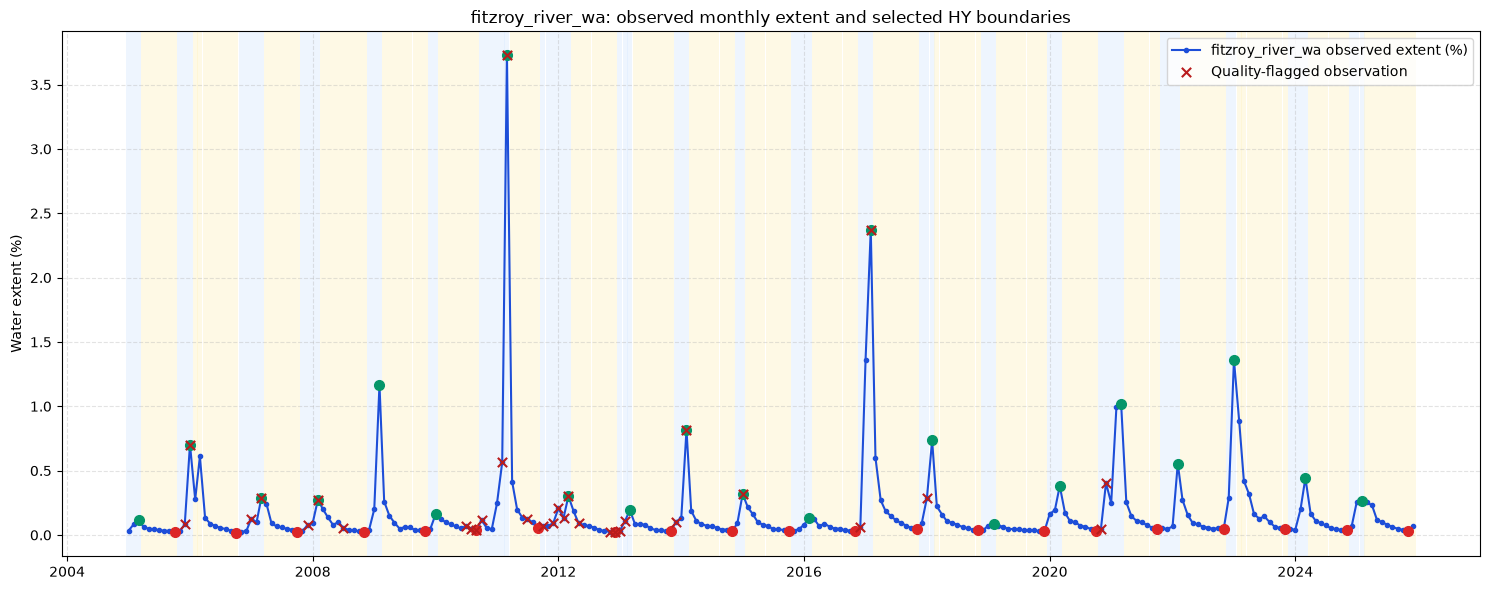

In [12]:
if plt is None:
    print("matplotlib is not installed; skipping inline plot. HTML report generation still works.")
else:
    fig, ax = plt.subplots(figsize=(15, 6))

    for ts, row in report_labels.iterrows():
        color = "#dbeafe" if row["season"] == "Wet" else "#fef3c7"
        ax.axvspan(ts - pd.Timedelta(days=15), ts + pd.Timedelta(days=15), color=color, alpha=0.45, linewidth=0)

    ax.plot(raw_extent.index, raw_extent["extent_pct"], color="#1d4ed8", marker="o", markersize=3, label=f"{CATCHMENT_KEY} observed extent (%)")
    flagged = quality.loc[quality["quality_flag"] != "usable"].dropna(subset=["extent_pct_raw"])
    if not flagged.empty:
        ax.scatter(flagged.index, flagged["extent_pct_raw"], color="#b91c1c", marker="x", s=45, label="Quality-flagged observation", zorder=4)

    for _, row in report_hydro_years.iterrows():
        ax.plot(pd.Timestamp(row["peak_month"]), row["peak_extent_pct"], marker="o", color="#059669", markersize=7)
        ax.plot(pd.Timestamp(row["end_dry_month"]), row["end_extent_pct"], marker="o", color="#dc2626", markersize=7)

    stress_years = set(surface_water_stress_screen["hy_year"]) if "hy_year" in surface_water_stress_screen else set()
    if state is not None:
        for _, row in state.hydro_years[state.hydro_years["hy_year"].isin(stress_years)].iterrows():
            if pd.notna(row["trough_month"]):
                ax.axvline(pd.Timestamp(row["trough_month"]), color="#7c2d12", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(f"{CATCHMENT_KEY}: observed monthly extent and selected HY boundaries")
    ax.set_ylabel("Water extent (%)")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()

## 9. Generate Interactive HTML Summary Report

The report is self-contained HTML and uses the selected primary HY result:
dynamic cycles for unimodal data, reviewed fixed windows for complex data.

In [13]:
print(f"Report source: {extent_source} | {DATA_PATH}")
print(f"Report extent rows: {len(raw_extent)} | {raw_extent.index.min().date()} to {raw_extent.index.max().date()}")
report_path = generate_html_report(
    extent=raw_extent,
    hydro_years=report_hydro_years,
    output_path=REPORT_PATH,
    title=(
        f"HydroSeason {CATCHMENT_KEY}: {int(quality['quality_flag'].ne('usable').sum())} flagged months; "
        f"invalid coverage above {MAX_INVALID_PCT}% may bias results; no fill applied"
    ),
)

print(f"HTML report written to: {report_path}")

Report source: csv | D:\RLH\5.6\repos\hydroseason\case_studies\data\extent\fitzroy_river_wa_30m.csv
Report extent rows: 252 | 2005-01-01 to 2025-12-01
HTML report written to: D:\RLH\5.6\repos\hydroseason\notebooks\output\04_under_the_hood\report.html
